In [88]:
import numpy as np
import scipy
import matplotlib.pyplot as plt


## Part A — Static graphene device and leads

### Cell A1: Imports and shared parameters

In [89]:
# ============================================================
# PART A — STATIC GRAPHENE DEVICE AND LEADS
#Cell A1: Imports and shared parameters
# ============================================================

# -----------------------------
# Energy unit
# -----------------------------
# All energies are measured in units of graphene hopping gamma.
# Physical graphene: gamma ≈ 2.7 eV.
gamma = 1.0

# -----------------------------
# ZGNR geometry
# -----------------------------
Ny = 29                 # ribbon width; one unit cell has 2*Ny atoms
N_orb = 2 * Ny          # number of orbitals per lead/device slice

# Number of longitudinal unit cells in the finite irradiated region.
#
# Nx = 30 is motivated by the finite-length geometry used in the paper,

Nx = 30

# Total number of orbitals in the central graphene region
N_device = Nx * N_orb

# -----------------------------
# Numerical tolerances
# -----------------------------
eta = 1e-8              # small imaginary broadening for retarded GFs

print("ZGNR width Ny                  =", Ny)
print("Atoms (Orbitals) per longitudinal cell =", N_orb)
print("Number of device cells Nx      =", Nx)
print("Total device orbitals          =", N_device)

ZGNR width Ny                  = 29
Atoms (Orbitals) per longitudinal cell = 58
Number of device cells Nx      = 30
Total device orbitals          = 1740


### Cell A2: Static ZGNR unit-cell Hamiltonian

In [90]:
# ============================================================
# Cell A2: Static ZGNR unit-cell Hamiltonian
# ============================================================

def zgnr_unit_cell(Ny, gamma=1.0):
    """
    Construct the static nearest-neighbor tight-binding matrices
    for a zigzag graphene nanoribbon.

    Returns
    -------
    H00 : ndarray
        Intracell Hamiltonian of one longitudinal ZGNR slice.

    H01 : ndarray
        Coupling from one longitudinal slice to the next.

    Notes
    -----
    One slice contains:
        A_0, B_0, A_1, B_1, ..., A_(Ny-1), B_(Ny-1)

    so its dimension is 2*Ny.
    """

    n_orb = 2 * Ny

    H00 = np.zeros((n_orb, n_orb), dtype=complex)
    H01 = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        """Index of sublattice-A orbital at transverse position j."""
        return 2 * j

    def B(j):
        """Index of sublattice-B orbital at transverse position j."""
        return 2 * j + 1

    # --------------------------------------------------------
    # Nearest-neighbor bonds inside one longitudinal unit cell
    # --------------------------------------------------------

    # A_j <-> B_j
    for j in range(Ny):
        H00[A(j), B(j)] = -gamma
        H00[B(j), A(j)] = -gamma

    # B_j <-> A_(j+1)
    for j in range(Ny - 1):
        H00[A(j + 1), B(j)] = -gamma
        H00[B(j), A(j + 1)] = -gamma

    # --------------------------------------------------------
    # Coupling between neighboring longitudinal unit cells
    # --------------------------------------------------------

    for j in range(Ny):
        H01[A(j), B(j)] = -gamma

    return H00, H01


# Construct the matrices only once
H00, H01 = zgnr_unit_cell(Ny, gamma)

print("H00 shape =", H00.shape)
print("H01 shape =", H01.shape)

print(
    "Hermiticity error of H00 =",
    np.linalg.norm(H00 - H00.conj().T)
)

H00 shape = (58, 58)
H01 shape = (58, 58)
Hermiticity error of H00 = 0.0


### Cell A3: Finite central graphene region

In [91]:
# ============================================================
# Cell A3: Finite central graphene region
# ============================================================

def build_finite_zgnr(H00, H01, Nx):
    """
    Construct a finite ZGNR consisting of Nx longitudinal slices.

    Parameters
    ----------
    H00 : ndarray
        Intracell Hamiltonian.

    H01 : ndarray
        Coupling from slice x to slice x+1.

    Nx : int
        Number of longitudinal slices.

    Returns
    -------
    H_device : ndarray
        Static Hamiltonian of the finite central region.
    """

    n_orb = H00.shape[0]
    n_total = Nx * n_orb

    H_device = np.zeros(
        (n_total, n_total),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_device[sl_x, sl_x] = H00

    # Couplings between neighboring longitudinal slices
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_device[sl_x, sl_next] = H01
        H_device[sl_next, sl_x] = H01.conj().T

    return H_device


H_device_static = build_finite_zgnr(
    H00,
    H01,
    Nx
)

# ------------------------------------------------------------
# Contact orbitals
# ------------------------------------------------------------
# The first longitudinal slice couples to the left lead.
left_contact = np.arange(
    0,
    N_orb
)

# The last longitudinal slice couples to the right lead.
right_contact = np.arange(
    (Nx - 1) * N_orb,
    Nx * N_orb
)

print("Static device shape =", H_device_static.shape)

print(
    "Device Hermiticity error =",
    np.linalg.norm(
        H_device_static
        - H_device_static.conj().T
    )
)

print("Number of left-contact orbitals  =", len(left_contact))
print("Number of right-contact orbitals =", len(right_contact))

Static device shape = (1740, 1740)
Device Hermiticity error = 0.0
Number of left-contact orbitals  = 58
Number of right-contact orbitals = 58


### Cell A4: Optional check of the static ZGNR band structure

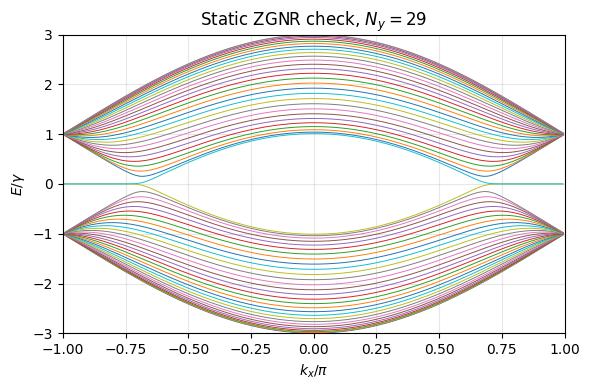

In [92]:
# ============================================================
# Cell A4: Optional check of the static ZGNR band structure
# ============================================================

def static_bloch_hamiltonian(k, H00, H01):
    """
    Static Bloch Hamiltonian of an infinite ZGNR.

    k is the dimensionless longitudinal Bloch momentum.
    """

    return (
        H00
        + H01 * np.exp(1j * k)
        + H01.conj().T * np.exp(-1j * k)
    )


Nk_check = 300

k_values = np.linspace(
    -np.pi,
    np.pi,
    Nk_check,
    endpoint=False
)

static_bands = np.zeros(
    (Nk_check, N_orb)
)

for ik, k in enumerate(k_values):

    Hk = static_bloch_hamiltonian(
        k,
        H00,
        H01
    )

    static_bands[ik] = np.linalg.eigvalsh(Hk)


plt.figure(figsize=(6, 4))

for band_index in range(N_orb):

    plt.plot(
        k_values / np.pi,
        static_bands[:, band_index],
        lw=0.7
    )

plt.xlabel(r"$k_x/\pi$")
plt.ylabel(r"$E/\gamma$")
plt.title(rf"Static ZGNR check, $N_y={Ny}$")

plt.xlim(-1, 1)
plt.ylim(-3, 3)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Part B — Driven graphene Floquet system

### Cell B1: Light and Floquet parameters

In [93]:
# ============================================================
# PART B — DRIVEN GRAPHENE FLOQUET SYSTEM
# Cell B1: Light and Floquet parameters
# ============================================================

# Circularly polarized light
z = 0.5                  # dimensionless light amplitude
omega = 3.0              # photon energy hbar*omega in units of gamma
#Here omega represents ℏω in units of γ, not an angular frequency in inverse second

# Floquet truncation
Nph = 4                  # begin with 1 for testing
sectors = np.arange(-Nph, Nph + 1)

# Number of phase points used for numerical Fourier integration
#this has no use in bessel fucntion mehtod
#N_phase = 200

# Small imaginary part in retarded Green functions
eta_floquet = 1e-6

# Floquet dimensions
Ndev = Nx * N_orb
NF = len(sectors) * Ndev

print("Light amplitude z       =", z)
print("Photon energy hbar*w    =", omega, "gamma")
print("Floquet sectors         =", sectors)
print("Static device dimension =", Ndev)
print("Floquet dimension       =", NF)

Light amplitude z       = 0.5
Photon energy hbar*w    = 3.0 gamma
Floquet sectors         = [-4 -3 -2 -1  0  1  2  3  4]
Static device dimension = 1740
Floquet dimension       = 15660


### Cell B2: Driven ZGNR unit-cell blocks

In [94]:
# ============================================================
# Cell B2: Driven ZGNR unit-cell blocks
# ============================================================

def driven_zgnr_unit_cell(phi, Ny, gamma=1.0, z=0.5):
    """
    Construct the time-dependent ZGNR blocks at phase phi = omega*t.

    Parameters
    ----------
    phi : float
        Dimensionless driving phase omega*t.

    Ny : int
        Ribbon width parameter.

    gamma : float
        Nearest-neighbor hopping.

    z : float
        Dimensionless circular-light amplitude.

    Returns
    -------
    H00_phi : ndarray
        Driven intracell Hamiltonian.

    H01_phi : ndarray
        Driven coupling from one longitudinal cell to the next.
    """

    n_orb = 2 * Ny

    H00_phi = np.zeros((n_orb, n_orb), dtype=complex)
    H01_phi = np.zeros((n_orb, n_orb), dtype=complex)

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    # Dimensionless vector-potential direction
    Ax = np.cos(phi)
    Ay = np.sin(phi)

    def peierls_phase(dx, dy):
        """
        exp[i 2z A(phi).r_ij]
        """
        return np.exp(
            1j * 2.0 * z * (Ax * dx + Ay * dy)
        )

    # Three nearest-neighbor graphene bond directions
    d1 = (0.0, 1.0)
    d2 = (np.sqrt(3.0) / 2.0, -0.5)
    d3 = (-np.sqrt(3.0) / 2.0, -0.5)

    # Bond type 1: A_j <-> B_j inside one cell
    hopping_1 = -gamma * peierls_phase(*d1)

    for j in range(Ny):
        H00_phi[A(j), B(j)] += hopping_1
        H00_phi[B(j), A(j)] += np.conj(hopping_1)

    # Bond type 2: B_j <-> A_(j+1) inside one cell
    hopping_2 = -gamma * peierls_phase(*d2)

    for j in range(Ny - 1):
        H00_phi[A(j + 1), B(j)] += hopping_2
        H00_phi[B(j), A(j + 1)] += np.conj(hopping_2)

    # Bond type 3: coupling to the next longitudinal cell
    hopping_3 = -gamma * peierls_phase(*d3)

    for j in range(Ny):
        H01_phi[A(j), B(j)] += hopping_3

    return H00_phi, H01_phi

#This is the essential 2D feature: the Peierls phase depends on the direction of each graphene bond

### Cell B3: Finite driven ZGNR Hamiltonian H(phi)

In [95]:
# ============================================================
# Cell B3: Finite driven ZGNR Hamiltonian H(phi)
# ============================================================

def build_driven_device(phi, Nx, Ny, gamma=1.0, z=0.5):
    """
    Construct the finite irradiated graphene Hamiltonian H(phi).
    """

    H00_phi, H01_phi = driven_zgnr_unit_cell(
        phi=phi,
        Ny=Ny,
        gamma=gamma,
        z=z
    )

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    H_phi = np.zeros(
        (n_device, n_device),
        dtype=complex
    )

    # Intracell blocks
    for x in range(Nx):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        H_phi[sl_x, sl_x] = H00_phi

    # Coupling between adjacent longitudinal cells
    for x in range(Nx - 1):

        sl_x = slice(
            x * n_orb,
            (x + 1) * n_orb
        )

        sl_next = slice(
            (x + 1) * n_orb,
            (x + 2) * n_orb
        )

        H_phi[sl_x, sl_next] = H01_phi
        H_phi[sl_next, sl_x] = H01_phi.conj().T

    return H_phi

#### Check Hermiticity at one arbitrary driving phase

In [96]:
# Check Hermiticity at one arbitrary driving phase

H_test = build_driven_device(
    phi=0.37,
    Nx=Nx,
    Ny=Ny,
    gamma=gamma,
    z=z
)

print(
    "Hermiticity error of H(phi) =",
    np.linalg.norm(H_test - H_test.conj().T)
)

Hermiticity error of H(phi) = 0.0


### Cell B4 (Bessel version): Analytic Fourier components H_m

B4 is now based on Bessel functions

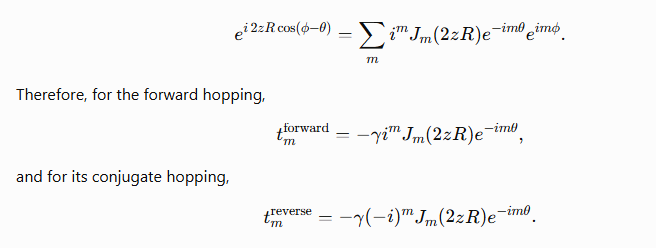

In [97]:
# ============================================================
# Cell B4 (Bessel version): Analytic Fourier components H_m
# via Jacobi-Anger expansion, replacing numerical phase-averaging.
# ============================================================

from scipy.special import jv  # Bessel functions of the first kind

def unit_cell_fourier_bessel(Ny, gamma=1.0, z=0.5, Mmax=2):
    """
    Analytic Fourier components H0_m, H1_m of the driven ZGNR
    unit-cell blocks, using the Jacobi-Anger expansion instead
    of numerical time-averaging.

    For a bond direction (dx, dy) with R = sqrt(dx^2+dy^2) and
    theta = atan2(dy, dx), the Peierls phase

        exp[i 2z (cos(phi) dx + sin(phi) dy)]
      = exp[i (2zR) cos(phi - theta)]

    has the exact expansion (paper's Eq. 6b):

        = sum_m  i^m J_m(2zR) e^{-im theta} e^{im phi}

    so the m-th Fourier component of a hopping term
    -gamma * peierls_phase(phi) is

        -gamma * i^m * J_m(2zR) * exp(-i m theta)

    and the m-th component of its Hermitian-conjugate hopping
    (used on the reversed bond) is

        -gamma * (-i)^m * J_m(2zR) * exp(-i m theta)

    (same J_m and same theta, only i^m -> (-i)^m).
    """

    n_orb = 2 * Ny

    def A(j):
        return 2 * j

    def B(j):
        return 2 * j + 1

    # Same three nearest-neighbor bond directions as in B2
    bonds = {
        "d1": (0.0, 1.0),
        "d2": (np.sqrt(3.0) / 2.0, -0.5),
        "d3": (-np.sqrt(3.0) / 2.0, -0.5),
    }

    R = {}
    theta = {}
    for name, (dx, dy) in bonds.items():
        R[name] = np.hypot(dx, dy)
        theta[name] = np.arctan2(dy, dx)

    H0m = {
        m: np.zeros((n_orb, n_orb), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }
    H1m = {
        m: np.zeros((n_orb, n_orb), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }

    for m in range(-Mmax, Mmax + 1):

        # --- Bond d1: A_j <-> B_j inside the cell ---
        x1 = 2.0 * z * R["d1"]
        fwd1 = -gamma * (1j**m) * jv(m, x1) * np.exp(-1j * m * theta["d1"])
        conj1 = -gamma * ((-1j)**m) * jv(m, x1) * np.exp(-1j * m * theta["d1"])

        for j in range(Ny):
            H0m[m][A(j), B(j)] += fwd1
            H0m[m][B(j), A(j)] += conj1

        # --- Bond d2: A_{j+1} <-> B_j inside the cell ---
        x2 = 2.0 * z * R["d2"]
        fwd2 = -gamma * (1j**m) * jv(m, x2) * np.exp(-1j * m * theta["d2"])
        conj2 = -gamma * ((-1j)**m) * jv(m, x2) * np.exp(-1j * m * theta["d2"])

        for j in range(Ny - 1):
            H0m[m][A(j + 1), B(j)] += fwd2
            H0m[m][B(j), A(j + 1)] += conj2

        # --- Bond d3: coupling to the next unit cell ---
        x3 = 2.0 * z * R["d3"]
        fwd3 = -gamma * (1j**m) * jv(m, x3) * np.exp(-1j * m * theta["d3"])

        for j in range(Ny):
            H1m[m][A(j), B(j)] += fwd3
            # H1's Hermitian partner lives in H1^dagger at the device
            # level (handled during device assembly), same as in B3.

    return H0m, H1m


def device_fourier_components(Nx, Ny, gamma=1.0, z=0.5, Mmax=2):
    """
    Bessel-based drop-in replacement for the original
    device_fourier_components(). Same signature, same output
    shape/keys: dict {m: (N_device, N_device) ndarray}.

    No N_phase / phase sampling needed.
    """

    n_orb = 2 * Ny
    n_device = Nx * n_orb

    H0m, H1m = unit_cell_fourier_bessel(Ny, gamma=gamma, z=z, Mmax=Mmax)

    H_fourier = {
        m: np.zeros((n_device, n_device), dtype=complex)
        for m in range(-Mmax, Mmax + 1)
    }

    for m in range(-Mmax, Mmax + 1):

        # Intracell blocks (same H0_m on every cell)
        for x in range(Nx):
            sl = slice(x * n_orb, (x + 1) * n_orb)
            H_fourier[m][sl, sl] = H0m[m]

        # Intercell couplings (same H1_m between every neighboring pair)
        for x in range(Nx - 1):
            sl_x = slice(x * n_orb, (x + 1) * n_orb)
            sl_next = slice((x + 1) * n_orb, (x + 2) * n_orb)

            H_fourier[m][sl_x, sl_next] = H1m[m]

    # H1^dagger contributes to H_{-m} at the (next, x) block —
    # add it via the Hermiticity of the full periodic H(t):
    # H_{-m} = H_m^dagger for the WHOLE Hamiltonian, so instead of
    # deriving H1^dagger's Fourier series separately, enforce it directly:
    for m in range(-Mmax, Mmax + 1):
        for x in range(Nx - 1):
            sl_x = slice(x * n_orb, (x + 1) * n_orb)
            sl_next = slice((x + 1) * n_orb, (x + 2) * n_orb)
            H_fourier[m][sl_next, sl_x] = H_fourier[-m][sl_x, sl_next].conj().T

    return H_fourier

In [98]:
# Sanity check: reconstruct H(phi) from Bessel H_m's and compare
# against the exact driven Hamiltonian from B2/B3.

Mmax_check = 10  # generous truncation for the check itself

H_fourier_check = device_fourier_components(
    Nx=Nx, Ny=Ny, gamma=gamma, z=z, Mmax=Mmax_check
)

phi_test = 0.83  # arbitrary test phase

H_reconstructed = sum(
    H_fourier_check[m] * np.exp(1j * m * phi_test)
    for m in range(-Mmax_check, Mmax_check + 1)
)

H_exact = build_driven_device(phi=phi_test, Nx=Nx, Ny=Ny, gamma=gamma, z=z)

print("Max reconstruction error =", np.max(np.abs(H_reconstructed - H_exact)))

Max reconstruction error = 2.3325759691995024e-11


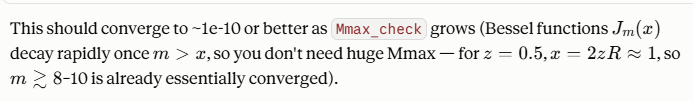

In [99]:
H_fourier = device_fourier_components(
    Nx=Nx, Ny=Ny, gamma=gamma, z=z, Mmax=2 * Nph
)

print("Calculated Fourier orders:")
print(sorted(H_fourier.keys()))

Calculated Fourier orders:
[-8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]


### Cell B5: Assemble H_F and Omega_F

In [100]:
# ============================================================
# Cell B5: Assemble H_F and Omega_F
# ============================================================

def assemble_floquet_matrices(
    H_fourier,
    Nph,
    omega
):
    """
    Construct:

        H_F[m,n] = H_(n-m)

    and

        Omega_F[m,m] = m*omega*I

    so that

        G^r(E) = [E I + Omega_F - H_F - Sigma^r]^{-1}.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_device = H_fourier[0].shape[0]
    n_floquet = len(sectors) * n_device

    HF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    OmegaF = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    eye_device = np.eye(
        n_device,
        dtype=complex
    )

    for a, m in enumerate(sectors):

        row = slice(
            a * n_device,
            (a + 1) * n_device
        )

        # Photon-energy block
        OmegaF[row, row] = m * omega * eye_device

        for b, n in enumerate(sectors):

            col = slice(
                b * n_device,
                (b + 1) * n_device
            )

            HF[row, col] = H_fourier[n - m]
            #you may retain m-n, but then you must define the expansion as
            #H(t)=q∑​Hq​exp(−iqωt) in B4 instead of ​exp(+iqωt).

    return HF, OmegaF

In [101]:
HF, OmegaF = assemble_floquet_matrices(
    H_fourier=H_fourier,
    Nph=Nph,
    omega=omega
)

print("HF shape     =", HF.shape)
print("OmegaF shape =", OmegaF.shape)

print(
    "Floquet-Hamiltonian Hermiticity error =",
    np.linalg.norm(HF - HF.conj().T)
)

HF shape     = (15660, 15660)
OmegaF shape = (15660, 15660)
Floquet-Hamiltonian Hermiticity error = 0.0


### Cell B6: Static ZGNR lead surface Green function

In [102]:
# ============================================================
# Cell B6: Static ZGNR lead surface Green function
# López–Sancho iterative method
# ============================================================

def sancho_surface_gf(
    E,
    H00,
    H01,
    eta=1e-9,
    max_iter=200,
    tol=1e-12
):
    """
    Surface retarded Green function of a semi-infinite
    periodic lead using the López–Sancho iteration.

    Parameters
    ----------
    E : float
        Energy.

    H00 : ndarray
        Hamiltonian of one lead unit cell.

    H01 : ndarray
        Coupling from cell i to cell i+1.

    eta : float
        Positive infinitesimal for the retarded Green function.

    Returns
    -------
    g_surface : ndarray
        Surface retarded Green function.
    """

    n_orb = H00.shape[0]
    identity = np.eye(n_orb, dtype=complex)

    z_matrix = (E + 1j * eta) * identity

    alpha = H01.copy()
    beta = H01.conj().T.copy()

    epsilon = H00.copy()
    epsilon_surface = H00.copy()

    for iteration in range(max_iter):

        g_bulk = np.linalg.inv(z_matrix - epsilon)

        epsilon_surface_new = (
            epsilon_surface
            + alpha @ g_bulk @ beta
        )

        epsilon_new = (
            epsilon
            + alpha @ g_bulk @ beta
            + beta @ g_bulk @ alpha
        )

        alpha_new = alpha @ g_bulk @ alpha
        beta_new = beta @ g_bulk @ beta

        if (
            np.linalg.norm(alpha_new) < tol
            and np.linalg.norm(beta_new) < tol
        ):
            epsilon_surface = epsilon_surface_new
            break

        epsilon_surface = epsilon_surface_new
        epsilon = epsilon_new
        alpha = alpha_new
        beta = beta_new

    else:
        print(
            f"Warning: López–Sancho did not converge "
            f"after {max_iter} iterations at E={E:.6f}"
        )

    g_surface = np.linalg.inv(
        z_matrix - epsilon_surface
    )

    return g_surface

#### Validate static ZGNR lead self-energy

In [103]:
# ============================================================
# Validate static ZGNR lead self-energy
# ============================================================

E_test = 0.5

# Right-facing surface
g_surface_R = sancho_surface_gf(
    E=E_test,
    H00=H00,
    H01=H01,
    eta=1e-6
)

Sigma_R_test = (
    H01
    @ g_surface_R
    @ H01.conj().T
)

Gamma_R_test = 1j * (
    Sigma_R_test
    - Sigma_R_test.conj().T
)

print("Surface GF shape =", g_surface_R.shape)

print(
    "Gamma_R Hermiticity error =",
    np.linalg.norm(
        Gamma_R_test
        - Gamma_R_test.conj().T
    )
)

print(
    "Minimum eigenvalue of Gamma_R =",
    np.min(np.linalg.eigvalsh(Gamma_R_test))
)

Surface GF shape = (58, 58)
Gamma_R Hermiticity error = 0.0
Minimum eigenvalue of Gamma_R = -7.892937584420095e-16


### Cell B7: Floquet self-energies of static ZGNR leads

In [104]:
# ============================================================
# Cell B7: Floquet self-energies of static ZGNR leads
# ============================================================

def graphene_floquet_self_energies(
    E,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Embed static ZGNR lead self-energies into Floquet space.

    The lead self-energies are diagonal in photon-sector index.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    SigmaL_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    SigmaR_F = np.zeros(
        (n_floquet, n_floquet),
        dtype=complex
    )

    for a, m in enumerate(sectors):

        sideband_energy = E + m * omega

        # Surface Green functions for right- and left-facing leads
        g_surface_R = sancho_surface_gf(
            sideband_energy,
            H00,
            H01,
            eta=eta
        )

        g_surface_L = sancho_surface_gf(
            sideband_energy,
            H00,
            H01.conj().T,
            eta=eta
        )

        # Self-energy blocks acting on one contact slice
        SigmaR_contact = (
            H01
            @ g_surface_R
            @ H01.conj().T
        )

        SigmaL_contact = (
            H01.conj().T
            @ g_surface_L
            @ H01
        )

        sector_offset = a * n_device

        left_block = slice(
            sector_offset,
            sector_offset + n_orb
        )

        right_block = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        SigmaL_F[left_block, left_block] = SigmaL_contact
        SigmaR_F[right_block, right_block] = SigmaR_contact

    return SigmaL_F, SigmaR_F

### Cell B8: Floquet retarded Green function

In [105]:
# ============================================================
# Cell B8: Floquet retarded Green function
# ============================================================

def graphene_floquet_green_function(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Calculate the full Floquet retarded Green function:

    G^r(E) = [E I + OmegaF - HF - SigmaL - SigmaR]^{-1}
    """

    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    n_floquet = HF.shape[0]

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    inverse_green = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    Gr = np.linalg.inv(inverse_green)

    return Gr, SigmaL_F, SigmaR_F

#### Gr shape

In [106]:
# Use a small Nx and Nph before attempting a large calculation.

E_test = 0.0

Gr_test, SigmaL_test, SigmaR_test = (
    graphene_floquet_green_function(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

print("Gr shape =", Gr_test.shape)



Gr shape = (15660, 15660)


### Cell B9: Numerical checks for Floquet Gr and lead broadenings

In [107]:
# ============================================================
# Cell B9: Numerical checks for Floquet Gr and lead broadenings
# ============================================================

print("Gr shape =", Gr_test.shape)

print("Any NaN in Gr =", np.isnan(Gr_test).any())
print("Any Inf in Gr =", np.isinf(Gr_test).any())

GammaL_test = 1j * (
    SigmaL_test - SigmaL_test.conj().T
)

GammaR_test = 1j * (
    SigmaR_test - SigmaR_test.conj().T
)

print(
    "GammaL Hermiticity error =",
    np.linalg.norm(
        GammaL_test - GammaL_test.conj().T
    )
)

print(
    "GammaR Hermiticity error =",
    np.linalg.norm(
        GammaR_test - GammaR_test.conj().T
    )
)

eig_GammaL = np.linalg.eigvalsh(GammaL_test)
eig_GammaR = np.linalg.eigvalsh(GammaR_test)

print("Minimum eigenvalue GammaL =", eig_GammaL.min())
print("Minimum eigenvalue GammaR =", eig_GammaR.min())

print("Maximum eigenvalue GammaL =", eig_GammaL.max())
print("Maximum eigenvalue GammaR =", eig_GammaR.max())

Gr shape = (15660, 15660)
Any NaN in Gr = False
Any Inf in Gr = False
GammaL Hermiticity error = 0.0
GammaR Hermiticity error = 0.0
Minimum eigenvalue GammaL = -8.132769895327107e-10
Minimum eigenvalue GammaR = -7.422316699254663e-10
Maximum eigenvalue GammaL = 1986290.6719625753
Maximum eigenvalue GammaR = 1986290.6719512856


##  Fig 3a from floquet-ti paper

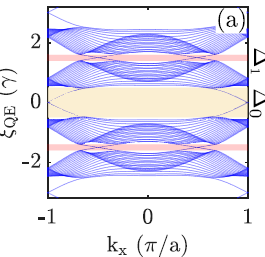

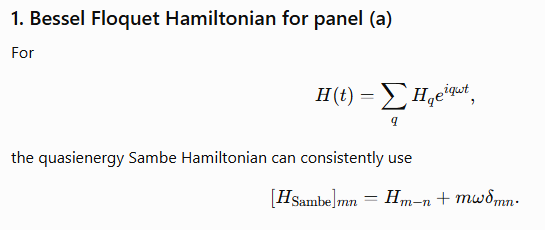

In [108]:
def floquet_bloch_H_bessel(
    k, Ny, gamma=1.0, z=0.5, omega=3.0, Nph=7
):
    """
    Bessel Floquet-Sambe Hamiltonian for an infinite ZGNR.
    Fourier convention:

        H(t) = sum_q H_q exp(+i q omega t)

    Sambe matrix:

        [H_S]_(m,n) = H_(m-n) + m*omega*delta_(m,n)
    """

    n_orb = 2 * Ny
    sectors = np.arange(-Nph, Nph + 1)
    Mmax = 2 * Nph

    H0m, H1m = unit_cell_fourier_bessel(
        Ny=Ny,
        gamma=gamma,
        z=z,
        Mmax=Mmax
    )

    dim = len(sectors) * n_orb
    H_sambe = np.zeros((dim, dim), dtype=complex)

    I_orb = np.eye(n_orb, dtype=complex)

    for a, m in enumerate(sectors):

        row = slice(a * n_orb, (a + 1) * n_orb)

        # Photon-sector energy
        H_sambe[row, row] += m * omega * I_orb

        for b, n in enumerate(sectors):

            col = slice(b * n_orb, (b + 1) * n_orb)
            q = m - n

            # Bloch Fourier component H_q(k)
            Hk_q = (
                H0m[q]
                + H1m[q] * np.exp(1j * k)
                + H1m[-q].conj().T * np.exp(-1j * k)
            )

            H_sambe[row, col] += Hk_q

    return H_sambe

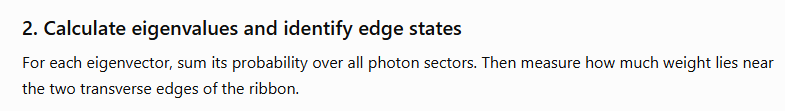

In [109]:
def transverse_edge_weight(eigenvectors, Ny, Nph, edge_rows=3):
    """
    Return the edge weight of every Floquet eigenstate.

    The probability is first summed over all photon sectors,
    giving the physical weight on the 2*Ny graphene orbitals.
    """

    n_orb = 2 * Ny
    n_sectors = 2 * Nph + 1
    n_states = eigenvectors.shape[1]

    # shape: photon sector, graphene orbital, eigenstate
    psi = eigenvectors.reshape(
        n_sectors,
        n_orb,
        n_states
    )

    orbital_probability = np.sum(
        np.abs(psi)**2,
        axis=0
    )

    edge_orbitals = []

    # Bottom edge: first transverse rows
    for j in range(edge_rows):
        edge_orbitals.extend([2*j, 2*j + 1])

    # Top edge: last transverse rows
    for j in range(Ny - edge_rows, Ny):
        edge_orbitals.extend([2*j, 2*j + 1])

    edge_orbitals = np.unique(edge_orbitals)

    return np.sum(
        orbital_probability[edge_orbitals, :],
        axis=0
    )

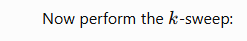

In [110]:
Nph_band = 7
Nk = 150

z = 0.5
omega = 3.0

Emin = -3.0
Emax = 3.0

k_values = np.linspace(
    -np.pi,
    np.pi,
    Nk,
    endpoint=True
)

all_k = []
all_E = []
all_edge_weight = []

for k in k_values:

    H_sambe = floquet_bloch_H_bessel(
        k=k,
        Ny=Ny,
        gamma=gamma,
        z=z,
        omega=omega,
        Nph=Nph_band
    )

    eigvals, eigvecs = np.linalg.eigh(H_sambe)

    keep = (
        (eigvals > Emin)
        & (eigvals < Emax)
    )

    eigvals = eigvals[keep]
    eigvecs = eigvecs[:, keep]

    edge_weight = transverse_edge_weight(
        eigvecs,
        Ny=Ny,
        Nph=Nph_band,
        edge_rows=3
    )

    all_k.append(
        np.full(eigvals.size, k / np.pi)
    )
    all_E.append(eigvals)
    all_edge_weight.append(edge_weight)

k_plot = np.concatenate(all_k)
E_plot = np.concatenate(all_E)
edge_weight_plot = np.concatenate(all_edge_weight)

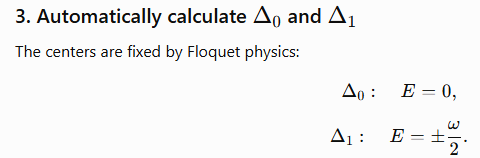

In [111]:
# States below this edge-weight threshold are treated as bulk-like.
# Check stability using, for example, 0.35, 0.40, and 0.45.
edge_threshold = 0.40

bulk_mask = edge_weight_plot < edge_threshold
bulk_energies = E_plot[bulk_mask]


def bulk_gap_around(E_center, bulk_energies):
    """
    Locate the nearest bulk states below and above E_center.
    Their energies define the bulk-gap boundaries.
    """

    below = bulk_energies[bulk_energies < E_center]
    above = bulk_energies[bulk_energies > E_center]

    if len(below) == 0 or len(above) == 0:
        return None

    lower_edge = np.max(below)
    upper_edge = np.min(above)

    if upper_edge <= lower_edge:
        return None

    return lower_edge, upper_edge


gap_Delta0 = bulk_gap_around(
    0.0,
    bulk_energies
)

gap_Delta1_plus = bulk_gap_around(
    +omega / 2,
    bulk_energies
)

gap_Delta1_minus = bulk_gap_around(
    -omega / 2,
    bulk_energies
)

print("Automatically calculated gaps:")

for name, gap in [
    ("Delta_0", gap_Delta0),
    ("Delta_1 (+)", gap_Delta1_plus),
    ("Delta_1 (-)", gap_Delta1_minus)
]:
    if gap is not None:
        lower, upper = gap

        print(
            f"{name}: "
            f"[{lower:+.6f}, {upper:+.6f}], "
            f"width = {upper-lower:.6f}"
        )

Automatically calculated gaps:
Delta_0: [-0.485093, +0.485093], width = 0.970186
Delta_1 (+): [+1.406047, +1.593953], width = 0.187905
Delta_1 (-): [-1.593953, -1.406047], width = 0.187905


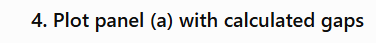

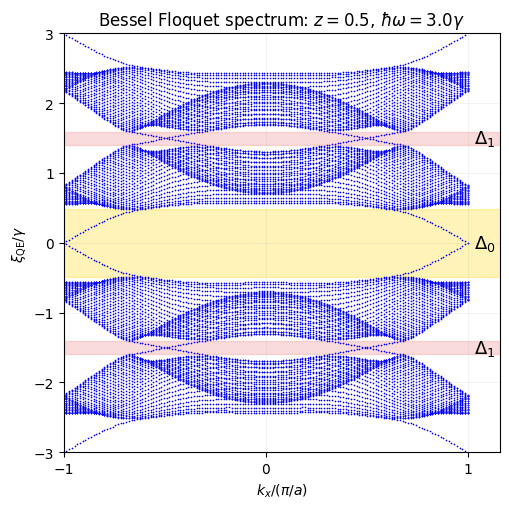

In [112]:
plt.figure(figsize=(5.2, 5.2))

# Plot all quasienergy states
plt.scatter(
    k_plot,
    E_plot,
    s=1.5,
    color="blue",
    linewidths=0
)

detected_gaps = [
    (r"$\Delta_0$", gap_Delta0, "gold"),
    (r"$\Delta_1$", gap_Delta1_plus, "lightcoral"),
    (r"$\Delta_1$", gap_Delta1_minus, "lightcoral")
]

for label, gap, color in detected_gaps:

    if gap is None:
        continue

    lower, upper = gap

    plt.axhspan(
        lower,
        upper,
        color=color,
        alpha=0.28,
        zorder=0
    )

    plt.text(
        1.03,
        0.5 * (lower + upper),
        label,
        fontsize=13,
        va="center"
    )

plt.xlabel(r"$k_x/(\pi/a)$")
plt.ylabel(r"$\xi_{\rm QE}/\gamma$")

plt.xlim(-1.0, 1.16)
plt.ylim(-3.0, 3.0)

plt.xticks([-1, 0, 1])
plt.grid(alpha=0.15)

plt.title(
    rf"Bessel Floquet spectrum: "
    rf"$z={z}$, $\hbar\omega={omega}\gamma$"
)

plt.tight_layout()
plt.show()

The reported gap boundaries should be tested for stability against Nk, edge_rows, and edge_threshold. If the boundaries move strongly when changing edge_threshold from 0.35 to 0.45, the bulk/edge classification needs refinement

In [113]:
threshold_values = [0.30, 0.35, 0.40, 0.45, 0.50]

print(
    f"{'threshold':>10} | "
    f"{'Delta0 lower':>12} {'Delta0 upper':>12} {'width':>10} | "
    f"{'Delta1 lower':>12} {'Delta1 upper':>12} {'width':>10}"
)

print("-" * 92)

for threshold in threshold_values:

    bulk_mask_test = edge_weight_plot < threshold
    bulk_E_test = E_plot[bulk_mask_test]

    gap0 = bulk_gap_around(
        0.0,
        bulk_E_test
    )

    gap1 = bulk_gap_around(
        omega / 2,
        bulk_E_test
    )

    if gap0 is not None and gap1 is not None:

        g0_lower, g0_upper = gap0
        g1_lower, g1_upper = gap1

        print(
            f"{threshold:10.2f} | "
            f"{g0_lower:12.5f} {g0_upper:12.5f} "
            f"{g0_upper-g0_lower:10.5f} | "
            f"{g1_lower:12.5f} {g1_upper:12.5f} "
            f"{g1_upper-g1_lower:10.5f}"
        )

 threshold | Delta0 lower Delta0 upper      width | Delta1 lower Delta1 upper      width
--------------------------------------------------------------------------------------------
      0.30 |     -0.48509      0.48509    0.97019 |      1.39301      1.60699    0.21399
      0.35 |     -0.48509      0.48509    0.97019 |      1.40134      1.59866    0.19731
      0.40 |     -0.48509      0.48509    0.97019 |      1.40605      1.59395    0.18791
      0.45 |     -0.48068      0.48068    0.96137 |      1.41269      1.58731    0.17462
      0.50 |     -0.48068      0.48068    0.96137 |      1.41920      1.58080    0.16159


## Part C — Graphene Floquet scattering matrices

### Cell C1: Hermitian matrix square root

In [114]:
# ============================================================
# PART C — FLOQUET SCATTERING MATRICES
# Cell C1: Hermitian matrix square root
# ============================================================

def hermitian_matrix_sqrt(matrix, eigenvalue_tol=1e-10):
    """
    Compute the positive-semidefinite square root
    of a Hermitian Gamma matrix.
    """

    matrix_H = 0.5 * (
        matrix + matrix.conj().T
    )

    eigenvalues, eigenvectors = np.linalg.eigh(matrix_H)

    scale = max(
        np.max(np.abs(eigenvalues)),
        1.0
    )

    cutoff = eigenvalue_tol * scale

    # Keep positive eigenvalues and remove tiny numerical negatives
    eigenvalues_clipped = np.where(
        eigenvalues > cutoff,
        eigenvalues,
        0.0
    )

    sqrt_matrix = (
        eigenvectors
        @ np.diag(np.sqrt(eigenvalues_clipped))
        @ eigenvectors.conj().T
    )

    return sqrt_matrix

### Cell C2: Static ZGNR contact Sigma and Gamma matrices

In [115]:
# ============================================================
# Cell C2: Static ZGNR contact Sigma and Gamma matrices
# ============================================================

def graphene_contact_matrices(
    energy,
    H00,
    H01,
    eta=1e-6
):
    """
    Compute contact self-energies and broadenings for the
    left and right static ZGNR leads at one energy.

    Returns
    -------
    contacts : dict
        SigmaL, SigmaR, GammaL, GammaR,
        sqrtGammaL, sqrtGammaR.
    """

    # Right-facing semi-infinite lead
    g_surface_R = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01,
        eta=eta
    )

    # Left-facing semi-infinite lead
    g_surface_L = sancho_surface_gf(
        E=energy,
        H00=H00,
        H01=H01.conj().T,
        eta=eta
    )

    SigmaR = (
        H01
        @ g_surface_R
        @ H01.conj().T
    )

    SigmaL = (
        H01.conj().T
        @ g_surface_L
        @ H01
    )

    GammaL = 1j * (
        SigmaL - SigmaL.conj().T
    )

    GammaR = 1j * (
        SigmaR - SigmaR.conj().T
    )

    sqrtGammaL = hermitian_matrix_sqrt(GammaL)
     

    sqrtGammaR = hermitian_matrix_sqrt(GammaR)
       
    

    return {
        "SigmaL": SigmaL,
        "SigmaR": SigmaR,
        "GammaL": GammaL,
        "GammaR": GammaR,
        "sqrtGammaL": sqrtGammaL,
        "sqrtGammaR": sqrtGammaR,
        
    }

### Cell C3: Selected contact columns of the Floquet Green function

In [116]:
# ============================================================
# Cell C3: Selected contact columns of the Floquet Green function
#solve only for columns corresponding to the left and right contacts of the incoming m=0 sector
# ============================================================

def graphene_contact_green_blocks(
    E,
    HF,
    OmegaF,
    H00,
    H01,
    Nx,
    Nph,
    omega,
    eta=1e-6
):
    """
    Compute only the Green-function columns needed for scattering:

        G^r_pp'(E_m, E)

    where the incoming electron is in Floquet sector 0 and
    the outgoing electron is in sector m.

    Returns
    -------
    G_by_m : dict
        G_by_m[m]["LL"], ["LR"], ["RL"], ["RR"],
        each of shape (N_orb, N_orb).

    SigmaL_F, SigmaR_F : ndarray
        Full Floquet lead self-energy matrices.
    """

    sectors = np.arange(-Nph, Nph + 1)

    n_orb = H00.shape[0]
    n_device = Nx * n_orb
    n_floquet = len(sectors) * n_device

    # Floquet self-energies at base energy E
    SigmaL_F, SigmaR_F = graphene_floquet_self_energies(
        E=E,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta
    )

    identity_F = np.eye(
        n_floquet,
        dtype=complex
    )

    A_matrix = (
        (E + 1j * eta) * identity_F
        + OmegaF
        - HF
        - SigmaL_F
        - SigmaR_F
    )

    # --------------------------------------------------------
    # Incoming sector is m = 0
    # --------------------------------------------------------

    a0 = np.where(sectors == 0)[0][0]
    sector0_offset = a0 * n_device

    incoming_left = np.arange(
        sector0_offset,
        sector0_offset + n_orb
    )

    incoming_right = np.arange(
        sector0_offset + (Nx - 1) * n_orb,
        sector0_offset + Nx * n_orb
    )

    # P selects only incoming L and R interface columns
    P_contacts = np.zeros(
        (n_floquet, 2 * n_orb),
        dtype=complex
    )

    P_contacts[incoming_left, :n_orb] = np.eye(
        n_orb,
        dtype=complex
    )

    P_contacts[incoming_right, n_orb:] = np.eye(
        n_orb,
        dtype=complex
    )

    # Solve:
    #
    # A X = P
    #
    # Therefore:
    #
    # X = G^r P
    #
    # X contains only the required contact columns.
    X = np.linalg.solve(
        A_matrix,
        P_contacts
    )

    G_by_m = {}

    for a, m in enumerate(sectors):

        sector_offset = a * n_device

        outgoing_left = slice(
            sector_offset,
            sector_offset + n_orb
        )

        outgoing_right = slice(
            sector_offset + (Nx - 1) * n_orb,
            sector_offset + Nx * n_orb
        )

        # First n_orb columns correspond to incoming L.
        # Last n_orb columns correspond to incoming R.
        GLL = X[outgoing_left, :n_orb]
        GLR = X[outgoing_left, n_orb:]

        GRL = X[outgoing_right, :n_orb]
        GRR = X[outgoing_right, n_orb:]

        G_by_m[int(m)] = {
            "LL": GLL,
            "LR": GLR,
            "RL": GRL,
            "RR": GRR
        }

    return G_by_m, SigmaL_F, SigmaR_F

### Cell C4: Fisher-Lee Floquet scattering matrices

In [117]:
# ============================================================
# Cell C4: Fisher-Lee Floquet scattering matrices
#Construct graphene Floquet scattering matrices
# ============================================================

def build_graphene_scattering_matrices(
    G_by_m,
    E,
    H00,
    H01,
    omega,
    eta=1e-6
):
    """
    Construct

        S_pp'(E_m, E)

    for every outgoing Floquet sector m using the
    generalized Fisher-Lee relation.

    Returns
    -------
    S_by_m : dict
        S_by_m[m]["LL"], ["LR"], ["RL"], ["RR"].
    """

    n_orb = H00.shape[0]
    identity_contact = np.eye(
        n_orb,
        dtype=complex
    )

    # Incoming broadenings at energy E
    incoming = graphene_contact_matrices(
        energy=E,
        H00=H00,
        H01=H01,
        eta=eta
    )

    sqrtGammaL_in = incoming["sqrtGammaL"]
    sqrtGammaR_in = incoming["sqrtGammaR"]

    S_by_m = {}

    for m, Gcontact in G_by_m.items():

        Em = E + m * omega

        # Outgoing broadenings at energy E_m
        outgoing = graphene_contact_matrices(
            energy=Em,
            H00=H00,
            H01=H01,
            eta=eta
        )

        sqrtGammaL_out = outgoing["sqrtGammaL"]
        sqrtGammaR_out = outgoing["sqrtGammaR"]

        delta_m0 = 1.0 if m == 0 else 0.0

        SLL = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaL_out
            @ Gcontact["LL"]
            @ sqrtGammaL_in
        )

        SLR = (
            -1j
            * sqrtGammaL_out
            @ Gcontact["LR"]
            @ sqrtGammaR_in
        )

        SRL = (
            -1j
            * sqrtGammaR_out
            @ Gcontact["RL"]
            @ sqrtGammaL_in
        )

        SRR = (
            delta_m0 * identity_contact
            - 1j
            * sqrtGammaR_out
            @ Gcontact["RR"]
            @ sqrtGammaR_in
        )

        S_by_m[m] = {
            "LL": SLL,
            "LR": SLR,
            "RL": SRL,
            "RR": SRR
        }

    return S_by_m, incoming

### Cell C5: Build contact Green functions and scattering matrices

In [118]:
expected_dim = (2 * Nph + 1) * Nx * N_orb

print("HF shape       =", HF.shape)
print("OmegaF shape   =", OmegaF.shape)
print("Expected shape =", (expected_dim, expected_dim))

HF shape       = (15660, 15660)
OmegaF shape   = (15660, 15660)
Expected shape = (15660, 15660)


In [119]:
# ============================================================
# Cell C5: Build contact Green functions and scattering matrices
# at one test energy
# ============================================================

E_test = 0.0

Gcontact_by_m, SigmaL_test, SigmaR_test = (
    graphene_contact_green_blocks(
        E=E_test,
        HF=HF,
        OmegaF=OmegaF,
        H00=H00,
        H01=H01,
        Nx=Nx,
        Nph=Nph,
        omega=omega,
        eta=eta_floquet
    )
)

S_by_m_test, incoming_contacts_test = (
    build_graphene_scattering_matrices(
        G_by_m=Gcontact_by_m,
        E=E_test,
        H00=H00,
        H01=H01,
        omega=omega,
        eta=eta_floquet
    )
)

for m in sorted(S_by_m_test):

    print(f"\nFloquet sector m = {m}")

    for key in ["LL", "LR", "RL", "RR"]:

        print(
            key,
            S_by_m_test[m][key].shape,
            "norm =",
            np.linalg.norm(
                S_by_m_test[m][key],
                ord="fro"
            )
        )


Floquet sector m = -4
LL (58, 58) norm = 2.4360896876508644e-07
LR (58, 58) norm = 1.8437613905972295e-07
RL (58, 58) norm = 1.843761391601901e-07
RR (58, 58) norm = 2.436089686653254e-07

Floquet sector m = -3
LL (58, 58) norm = 2.100510996347347e-06
LR (58, 58) norm = 2.6470003540974554e-06
RL (58, 58) norm = 2.647000355567126e-06
RR (58, 58) norm = 2.100510995074553e-06

Floquet sector m = -2
LL (58, 58) norm = 2.2187983566469762e-05
LR (58, 58) norm = 2.017243538104248e-05
RL (58, 58) norm = 2.0172435392089873e-05
RR (58, 58) norm = 2.2187983558263165e-05

Floquet sector m = -1
LL (58, 58) norm = 0.0005372488044859413
LR (58, 58) norm = 0.000839910419238507
RL (58, 58) norm = 0.0008399104197110619
RR (58, 58) norm = 0.0005372488040079933

Floquet sector m = 0
LL (58, 58) norm = 7.559102716640065
LR (58, 58) norm = 0.9272349067923296
RL (58, 58) norm = 0.927234907271005
RR (58, 58) norm = 7.559102716596684

Floquet sector m = 1
LL (58, 58) norm = 0.0005372488042682212
LR (58, 58) n

In [120]:
print("Nph used in C5 =", Nph)
print("HF shape       =", HF.shape)
print("Scattering sectors =", sorted(S_by_m_test.keys()))
print("Number of sectors  =", len(S_by_m_test))

Nph used in C5 = 4
HF shape       = (15660, 15660)
Scattering sectors = [-4, -3, -2, -1, 0, 1, 2, 3, 4]
Number of sectors  = 9


### Cell C6: Floquet scattering-matrix unitarity

In [121]:
# ============================================================
# Cell C6: Floquet scattering-matrix unitarity
# Directly in the graphene contact-orbital space
# ============================================================

def check_graphene_floquet_unitarity(S_by_m):
    """
    Check the Floquet scattering-matrix unitarity relations

        sum_m [S_LL^dagger(m) S_LL(m)
             + S_RL^dagger(m) S_RL(m)] = I

    for electrons incident from the left lead, and

        sum_m [S_LR^dagger(m) S_LR(m)
             + S_RR^dagger(m) S_RR(m)] = I

    for electrons incident from the right lead.

    All matrices act in the graphene contact-orbital space.
    """

    first_sector = next(iter(S_by_m.values()))
    n_contact = first_sector["LL"].shape[0]

    U_in_L = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    U_in_R = np.zeros(
        (n_contact, n_contact),
        dtype=complex
    )

    for m in sorted(S_by_m):

        S = S_by_m[m]

        # Electron incident from the left lead:
        # it can exit into either L or R
        U_in_L += (
            S["LL"].conj().T @ S["LL"]
            + S["RL"].conj().T @ S["RL"]
        )

        # Electron incident from the right lead:
        # it can exit into either L or R
        U_in_R += (
            S["LR"].conj().T @ S["LR"]
            + S["RR"].conj().T @ S["RR"]
        )

    I_contact = np.eye(
        n_contact,
        dtype=complex
    )

    error_L = np.linalg.norm(
        U_in_L - I_contact,
        ord="fro"
    )

    error_R = np.linalg.norm(
        U_in_R - I_contact,
        ord="fro"
    )

    max_error_L = np.max(
        np.abs(U_in_L - I_contact)
    )

    max_error_R = np.max(
        np.abs(U_in_R - I_contact)
    )

    print("Contact-space dimension =", n_contact)

    print(
        "Frobenius unitarity error, incidence from L =",
        error_L
    )

    print(
        "Frobenius unitarity error, incidence from R =",
        error_R
    )

    print(
        "Maximum elementwise error, incidence from L =",
        max_error_L
    )

    print(
        "Maximum elementwise error, incidence from R =",
        max_error_R
    )

    return {
        "U_in_L": U_in_L,
        "U_in_R": U_in_R,
        "error_L": error_L,
        "error_R": error_R,
        "max_error_L": max_error_L,
        "max_error_R": max_error_R
    }

#### unitarity_check

In [122]:
unitarity_results = check_graphene_floquet_unitarity(
    S_by_m=S_by_m_test
)

Contact-space dimension = 58
Frobenius unitarity error, incidence from L = 0.0001950923509534729
Frobenius unitarity error, incidence from R = 0.00019509383449710585
Maximum elementwise error, incidence from L = 4.0867657964738235e-05
Maximum elementwise error, incidence from R = 4.0867906706876234e-05
